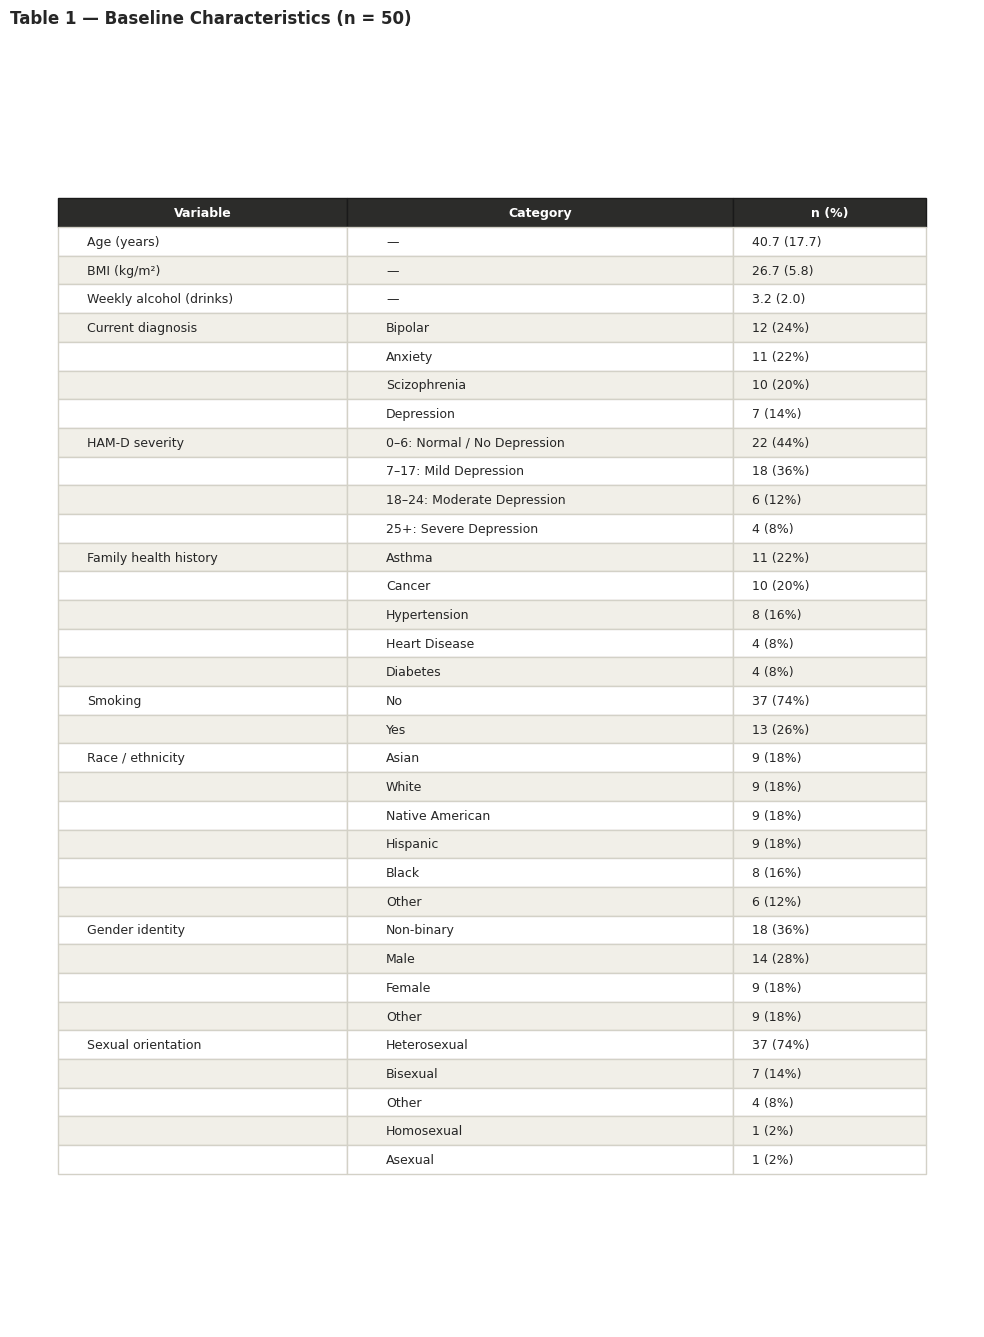

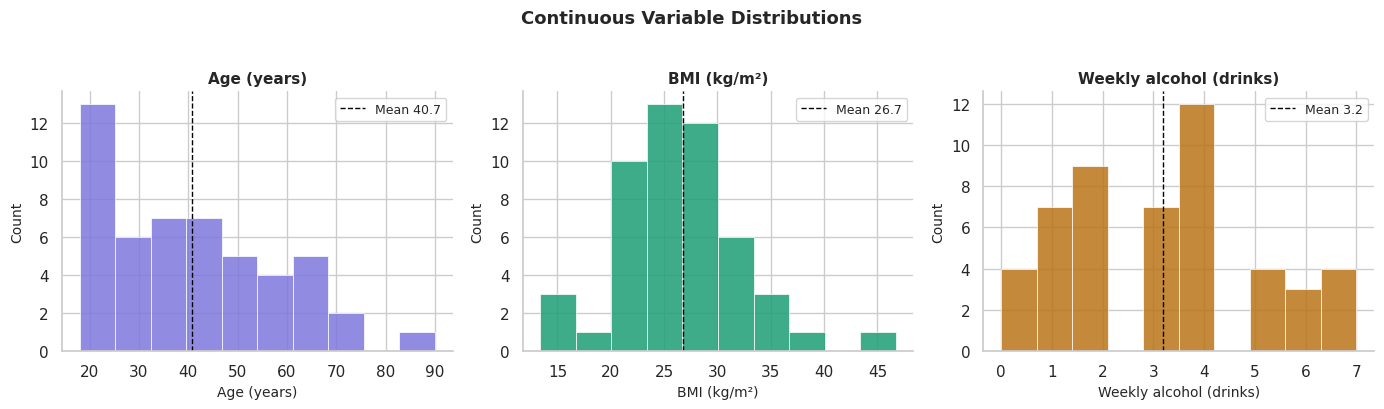

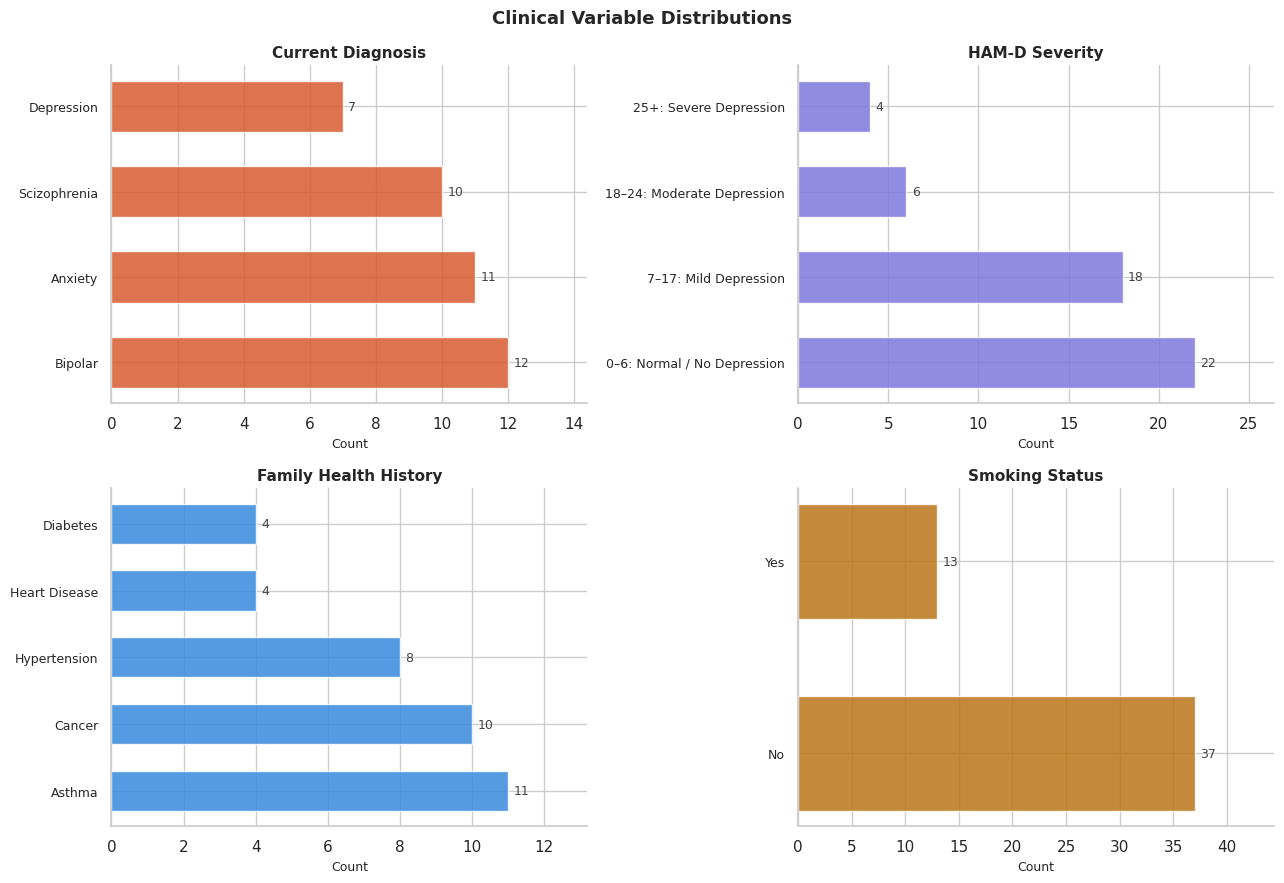

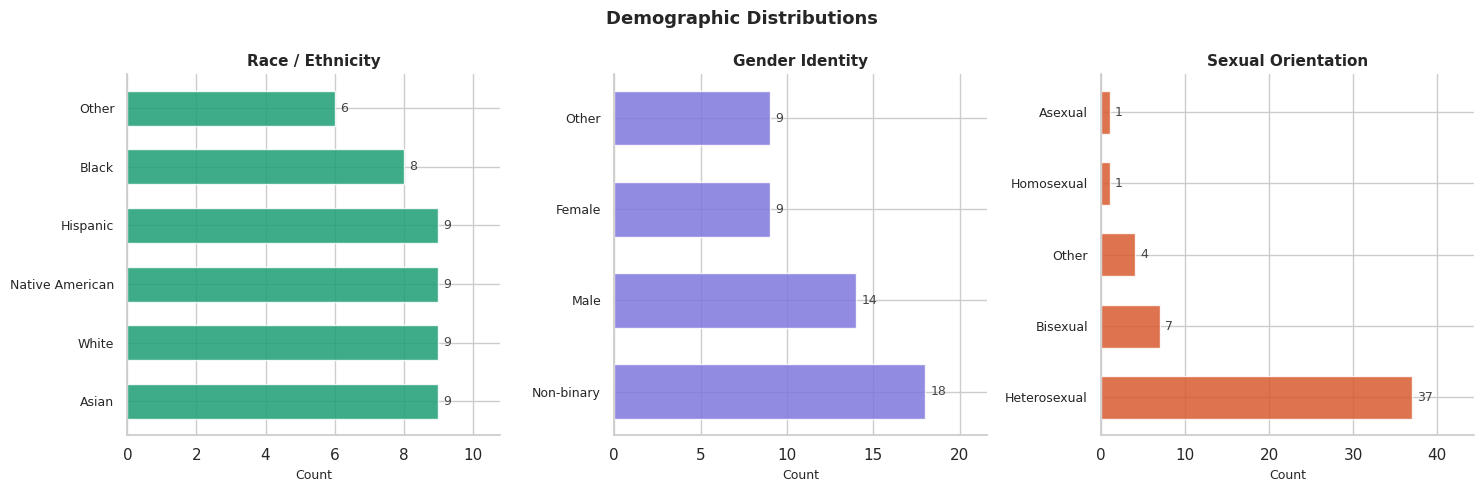

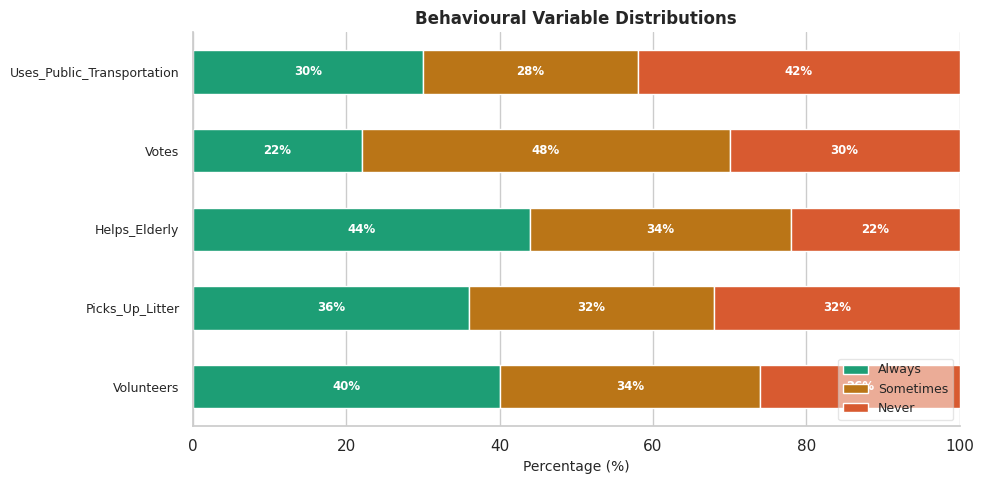

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import to_rgba

df = pd.read_csv("synthetic_data1.csv")

# ── Palette ────────────────────────────────────────────────────────────────────
PURPLE = "#7F77DD"
TEAL   = "#1D9E75"
CORAL  = "#D85A30"
BLUE   = "#378ADD"
AMBER  = "#BA7517"

sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})


# ── 1. TABLE 1 ─────────────────────────────────────────────────────────────────
# Continuous: mean (SD), median, range
cont_vars = {"Age": "Age (years)", "BMI": "BMI (kg/m²)", "Weekly_Alcohol_Intake": "Weekly alcohol (drinks)"}

rows = []
for col, label in cont_vars.items():
    s = df[col]
    rows.append({
        "Variable": label,
        "Category": "—",
        "n (%)": f"{s.mean():.1f} ({s.std():.1f})",
        "Stat": "Mean (SD)"
    })

# Categorical: n (%)
cat_vars = {
    "Current_Diagnosis":   "Current diagnosis",
    "HAM-D":               "HAM-D severity",
    "Family_Health_History": "Family health history",
    "Smoking":             "Smoking",
    "Race":                "Race / ethnicity",
    "Gender":              "Gender identity",
    "Sexual_Orientation":  "Sexual orientation",
}

for col, label in cat_vars.items():
    vc = df[col].value_counts()
    for i, (cat, n) in enumerate(vc.items()):
        rows.append({
            "Variable": label if i == 0 else "",
            "Category": cat,
            "n (%)": f"{n} ({100*n/len(df):.0f}%)",
            "Stat": ""
        })

table1 = pd.DataFrame(rows)[["Variable", "Category", "n (%)"]]

# Render as a matplotlib table (presentation-ready)
fig, ax = plt.subplots(figsize=(10, len(table1) * 0.38 + 1))
ax.axis("off")
tbl = ax.table(
    cellText=table1.values,
    colLabels=table1.columns,
    cellLoc="left",
    loc="center",
    colWidths=[0.3, 0.4, 0.2],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.4)

# Style header
for j in range(len(table1.columns)):
    tbl[0, j].set_facecolor("#2C2C2A")
    tbl[0, j].set_text_props(color="white", fontweight="bold")

# Alternating row shading
for i in range(1, len(table1) + 1):
    color = "#F1EFE8" if i % 2 == 0 else "white"
    for j in range(len(table1.columns)):
        tbl[i, j].set_facecolor(color)
        tbl[i, j].set_edgecolor("#D3D1C7")

plt.title("Table 1 — Baseline Characteristics (n = 50)",
          fontsize=12, fontweight="bold", pad=16, loc="left")
plt.tight_layout()
plt.savefig("table1.png", dpi=200, bbox_inches="tight")
plt.show()


# ── 2. CONTINUOUS DISTRIBUTIONS ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (col, label, color) in zip(axes, [
    ("Age",                  "Age (years)",           PURPLE),
    ("BMI",                  "BMI (kg/m²)",           TEAL),
    ("Weekly_Alcohol_Intake","Weekly alcohol (drinks)",AMBER),
]):
    sns.histplot(df[col], bins=10, color=color, alpha=0.85, ax=ax, edgecolor="white", linewidth=0.5)
    ax.axvline(df[col].mean(), color="black", linestyle="--", linewidth=1, label=f"Mean {df[col].mean():.1f}")
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.legend(fontsize=9)
    ax.set_title(label, fontsize=11, fontweight="bold")

plt.suptitle("Continuous Variable Distributions", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("continuous_distributions.png", dpi=200, bbox_inches="tight")
plt.show()


# ── 3. CLINICAL CATEGORICALS ───────────────────────────────────────────────────
clinical_cats = {
    "Current_Diagnosis":     ("Current Diagnosis",     CORAL),
    "HAM-D":                 ("HAM-D Severity",        PURPLE),
    "Family_Health_History": ("Family Health History", BLUE),
    "Smoking":               ("Smoking Status",        AMBER),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (col, (label, color)) in zip(axes.flat, clinical_cats.items()):
    vc = df[col].value_counts()
    bars = ax.barh(vc.index, vc.values, color=color, alpha=0.85, edgecolor="white", height=0.6)
    ax.bar_label(bars, fmt="%d", padding=4, fontsize=9, color="#444")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Count", fontsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.set_xlim(0, vc.max() * 1.2)

plt.suptitle("Clinical Variable Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("clinical_distributions.png", dpi=200, bbox_inches="tight")
plt.show()


# ── 4. DEMOGRAPHIC CATEGORICALS ────────────────────────────────────────────────
demo_cats = {
    "Race":               ("Race / Ethnicity",    TEAL),
    "Gender":             ("Gender Identity",     PURPLE),
    "Sexual_Orientation": ("Sexual Orientation",  CORAL),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (col, (label, color)) in zip(axes, demo_cats.items()):
    vc = df[col].value_counts()
    bars = ax.barh(vc.index, vc.values, color=color, alpha=0.85, edgecolor="white", height=0.6)
    ax.bar_label(bars, fmt="%d", padding=4, fontsize=9, color="#444")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Count", fontsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.set_xlim(0, vc.max() * 1.2)

plt.suptitle("Demographic Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("demographic_distributions.png", dpi=200, bbox_inches="tight")
plt.show()


# ── 5. BEHAVIOURAL VARIABLES (stacked bar) ─────────────────────────────────────
behav_vars = ["Volunteers", "Picks_Up_Litter", "Helps_Elderly",
              "Votes", "Uses_Public_Transportation"]

order = ["Always", "Sometimes", "Never"]
behav_colors = [TEAL, AMBER, CORAL]

behav_df = pd.DataFrame({
    var: df[var].value_counts(normalize=True).reindex(order, fill_value=0) * 100
    for var in behav_vars
}).T

fig, ax = plt.subplots(figsize=(10, 5))
bottom = pd.Series([0.0] * len(behav_df), index=behav_df.index)
for cat, color in zip(order, behav_colors):
    bars = ax.barh(behav_df.index, behav_df[cat], left=bottom,
                   color=color, label=cat, edgecolor="white", height=0.55)
    for bar, val in zip(bars, behav_df[cat]):
        if val > 8:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                    f"{val:.0f}%", ha="center", va="center", fontsize=8.5,
                    color="white", fontweight="bold")
    bottom += behav_df[cat]

ax.set_xlabel("Percentage (%)", fontsize=10)
ax.set_xlim(0, 100)
ax.legend(loc="lower right", fontsize=9, framealpha=0.5)
ax.tick_params(axis="y", labelsize=9)
ax.set_title("Behavioural Variable Distributions", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("behavioural_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

In [4]:
print(df.columns[:16].tolist())

['Unnamed: 0', 'Age', 'BMI', 'Family_Health_History', 'Current_Diagnosis', 'Race', 'Gender', 'Sexual_Orientation', 'Weekly_Alcohol_Intake', 'Smoking', 'HAM-D', 'Been_Sad_or_Fatigued', 'Loss_of_Interest', 'Hours_of_Sleep', 'Employment', 'Socioeconomic_Status']


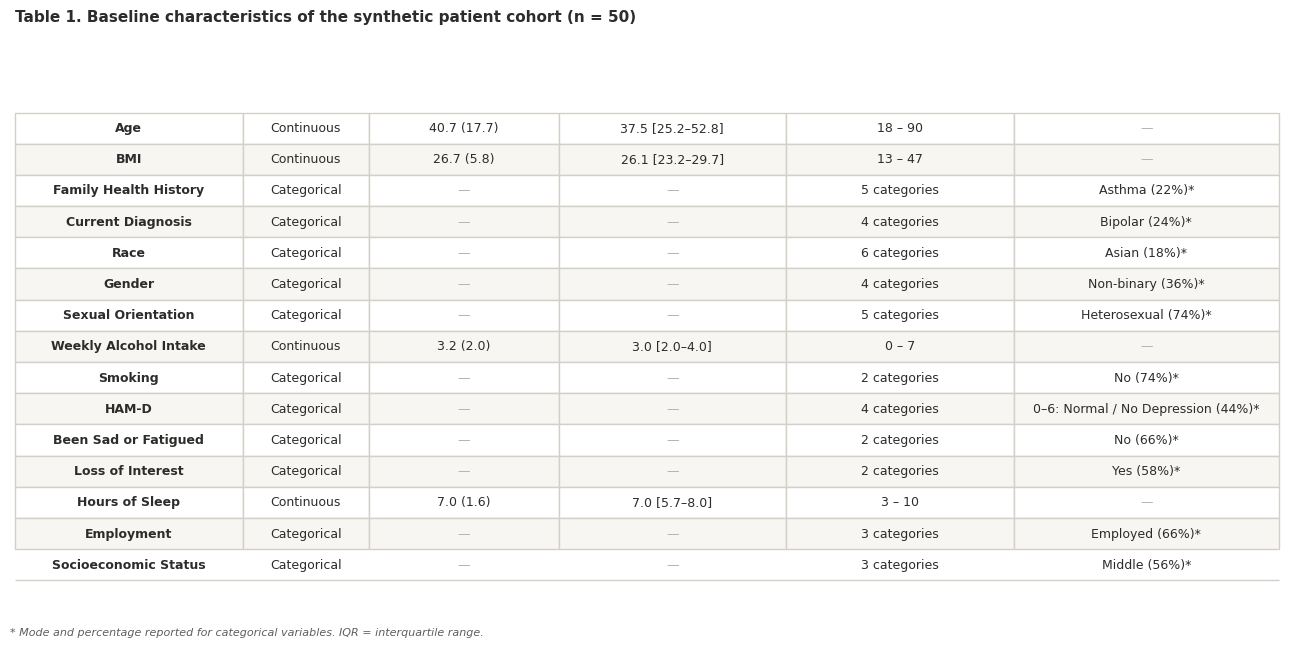

Saved: table1_baseline1.png


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

df = pd.read_csv("synthetic_data1.csv")
baseline_vars = df.columns[1:16].tolist()

# =========================================================
# Build summary rows
# =========================================================
rows = []
for col in baseline_vars:
    s = df[col].dropna()
    if pd.api.types.is_numeric_dtype(s):
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        rows.append({
            "Variable":  col.replace("_", " "),
            "Type":      "Continuous",
            "Mean (SD)": f"{s.mean():.1f} ({s.std():.1f})",
            "Median [IQR]": f"{s.median():.1f} [{q1:.1f}–{q3:.1f}]",
            "Range":     f"{s.min():.0f} – {s.max():.0f}",
            "n (%)":     "—",
        })
    else:
        mode = s.mode()[0]
        mode_n = (s == mode).sum()
        mode_pct = 100 * mode_n / len(df)
        n_cats = s.nunique()
        rows.append({
            "Variable":     col.replace("_", " "),
            "Type":         "Categorical",
            "Mean (SD)":    "—",
            "Median [IQR]": "—",
            "Range":        f"{n_cats} categories",
            "n (%)":        f"{mode} ({mode_pct:.0f}%)*",
        })

summary = pd.DataFrame(rows)

# =========================================================
# Render as paper-style table
# =========================================================
fig, ax = plt.subplots(figsize=(13, 6.5))
ax.axis("off")

col_labels = ["Variable", "Type", "Mean (SD)", "Median [IQR]", "Range / Categories", "Mode (%)"]
col_widths  = [0.18, 0.10, 0.15, 0.18, 0.18, 0.21]

cell_data = summary[["Variable", "Type", "Mean (SD)", "Median [IQR]", "Range", "n (%)"]].values.tolist()

tbl = ax.table(
    cellText=cell_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    colWidths=col_widths,
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

# Header styling
for j in range(len(col_labels)):
    cell = tbl[0, j]
    cell.set_facecolor("#2C2C2A")
    cell.set_text_props(color="white", fontweight="bold", fontsize=9)
    cell.set_edgecolor("white")

# Row styling
for i in range(1, len(cell_data) + 1):
    row_data = summary.iloc[i - 1]
    is_continuous = row_data["Type"] == "Continuous"
    for j in range(len(col_labels)):
        cell = tbl[i, j]
        cell.set_facecolor("#F7F6F2" if i % 2 == 0 else "white")
        cell.set_edgecolor("#D3D1C7")
        cell.set_text_props(fontsize=9, color="#2C2C2A")
        # Bold variable name
        if j == 0:
            cell.set_text_props(fontweight="bold", fontsize=9, color="#2C2C2A")
        # Dim irrelevant cells
        if is_continuous and j == 5:
            cell.set_text_props(color="#B4B2A9", fontsize=9)
        if not is_continuous and j in [2, 3]:
            cell.set_text_props(color="#B4B2A9", fontsize=9)

# Top and bottom border
for j in range(len(col_labels)):
    tbl[0, j].visible_edges = "TB"
    tbl[len(cell_data), j].visible_edges = "B"

plt.title(
    "Table 1. Baseline characteristics of the synthetic patient cohort (n = 50)",
    fontsize=11, fontweight="bold", loc="left", pad=12, color="#2C2C2A"
)

footnote = "* Mode and percentage reported for categorical variables. IQR = interquartile range."
fig.text(0.01, 0.01, footnote, fontsize=8, color="#5F5E5A", style="italic")

plt.tight_layout()
plt.savefig("table1_baseline1.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: table1_baseline1.png")

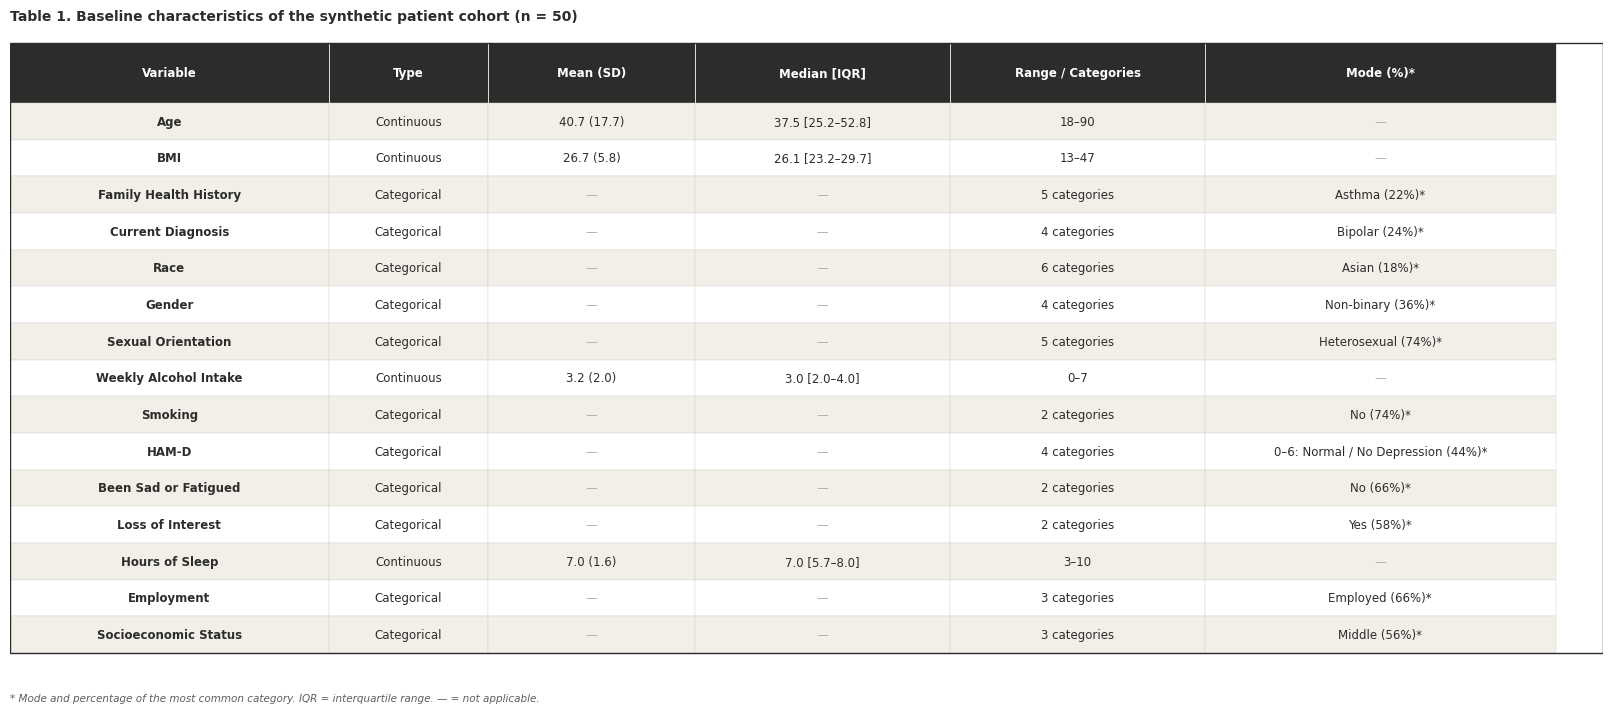

Saved: table1_baseline.png


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

df = pd.read_csv("synthetic_data1.csv")
baseline_vars = df.columns[1:16].tolist()

# =========================================================
# Build summary rows
# =========================================================
rows = []
for col in baseline_vars:
    s = df[col].dropna()
    if pd.api.types.is_numeric_dtype(s):
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        rows.append([
            col.replace("_", " "),
            "Continuous",
            f"{s.mean():.1f} ({s.std():.1f})",
            f"{s.median():.1f} [{q1:.1f}–{q3:.1f}]",
            f"{s.min():.0f}–{s.max():.0f}",
            "—",
        ])
    else:
        mode = s.mode()[0]
        pct  = 100 * (s == mode).sum() / len(df)
        rows.append([
            col.replace("_", " "),
            "Categorical",
            "—",
            "—",
            f"{s.nunique()} categories",
            f"{mode} ({pct:.0f}%)*",
        ])

col_labels = [
    "Variable",
    "Type",
    "Mean (SD)",
    "Median [IQR]",
    "Range / Categories",
    "Mode (%)*",
]

n_rows = len(rows)
n_cols = len(col_labels)

# =========================================================
# Manual cell-by-cell rendering
# =========================================================
col_widths  = [0.20, 0.10, 0.13, 0.16, 0.16, 0.22]  # fractions of figure width
row_height  = 0.055
header_h    = 0.09
fig_w, fig_h = 16, 1 + n_rows * 0.4

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# compute cumulative x positions
xs = np.cumsum([0] + col_widths[:-1])

# y positions: header at top, rows below
total_h = header_h + n_rows * row_height
y_top   = 0.97

# ── Draw header ───────────────────────────────────────────
for j, (label, x, w) in enumerate(zip(col_labels, xs, col_widths)):
    rect = mpatches.FancyBboxPatch(
        (x, y_top - header_h), w, header_h,
        boxstyle="square,pad=0",
        linewidth=0.5, edgecolor="white",
        facecolor="#2C2C2A"
    )
    ax.add_patch(rect)
    ax.text(
        x + w / 2, y_top - header_h / 2,
        label, ha="center", va="center",
        fontsize=8.5, fontweight="bold", color="white",
        wrap=True
    )

# ── Draw data rows ────────────────────────────────────────
for i, row in enumerate(rows):
    y_row = y_top - header_h - (i + 1) * row_height
    bg    = "#F1EFE8" if i % 2 == 0 else "white"
    is_cont = row[1] == "Continuous"

    for j, (val, x, w) in enumerate(zip(row, xs, col_widths)):
        rect = mpatches.FancyBboxPatch(
            (x, y_row), w, row_height,
            boxstyle="square,pad=0",
            linewidth=0.3, edgecolor="#D3D1C7",
            facecolor=bg
        )
        ax.add_patch(rect)

        # text colour: dim dashes
        if (is_cont and j == 5) or (not is_cont and j in [2, 3]):
            color = "#B4B2A9"
        else:
            color = "#2C2C2A"

        fw = "bold" if j == 0 else "normal"
        ax.text(
            x + w / 2, y_row + row_height / 2,
            str(val), ha="center", va="center",
            fontsize=8.5, color=color, fontweight=fw
        )

# ── Outer border ──────────────────────────────────────────
total_table_h = header_h + n_rows * row_height
outer = mpatches.FancyBboxPatch(
    (0, y_top - total_table_h), 1, total_table_h,
    boxstyle="square,pad=0",
    linewidth=1, edgecolor="#2C2C2A", facecolor="none"
)
ax.add_patch(outer)

# ── Title and footnote ────────────────────────────────────
ax.text(
    0, 1.0,
    "Table 1. Baseline characteristics of the synthetic patient cohort (n = 50)",
    ha="left", va="bottom", fontsize=10, fontweight="bold",
    color="#2C2C2A", transform=ax.transAxes
)
ax.text(
    0, y_top - total_table_h - 0.06,
    "* Mode and percentage of the most common category. "
    "IQR = interquartile range. — = not applicable.",
    ha="left", va="top", fontsize=7.5, color="#5F5E5A",
    style="italic", transform=ax.transAxes
)

plt.tight_layout(pad=0.2)
plt.savefig("table1_baseline.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: table1_baseline.png")

In [14]:
plt.savefig("table1_baseline.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>